## 1. Thư viện cần thiết

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
import random

In [2]:
# Đường lnk lấy dataset
axial_train_dataset = '/kaggle/input/brain-tumor-by-plane-object-detection/axial_t1wce_2_class/train/'
coronal_train_dataset = '/kaggle/input/brain-tumor-by-plane-object-detection/coronal_t1wce_2_class/train/'
sagittal_train_dataset = '/kaggle/input/brain-tumor-by-plane-object-detection/sagittal_t1wce_2_class/train/'
axial_test_dataset = '/kaggle/input/brain-tumor-by-plane-object-detection/axial_t1wce_2_class/test/'
coronal_test_dataset = '/kaggle/input/brain-tumor-by-plane-object-detection/coronal_t1wce_2_class/test/'
sagittal_test_dataset = '/kaggle/input/brain-tumor-by-plane-object-detection/sagittal_t1wce_2_class/test/'

## 2. Trực quan hóa dữ liệu

In [3]:
def read_images_and_labels(image_dir, label_dir):
    image_list = []
    label_files_list = []
    
    # Lặp qua tất cả các file trong thư mục label
    for label_file in os.listdir(label_dir):
        if label_file.endswith('.txt'):
            image_name = os.path.splitext(label_file)[0] + '.jpg'
            image_path = os.path.join(image_dir, image_name)
            
            # Kiểm tra nếu file ảnh tồn tại
            if os.path.exists(image_path):
                # Đọc ảnh và chuyển sang ảnh xám
                image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
                if image is not None:
                    image_list.append(image)
                    label_files_list.append(label_file)
    
    return image_list, label_files_list

In [4]:
def plot_images_with_bboxes(image_list, label_files_list, label_dir, title):
    selected_indices = random.sample(range(len(image_list)), 10)  # Lấy ngẫu nhiên 10 ảnh
    
    fig, axes = plt.subplots(2, 5, figsize=(20, 9))
    axes = axes.flatten()
    fig.suptitle(title)
    
    for i, idx in enumerate(selected_indices):
        image = image_list[idx]
        label_file = label_files_list[idx]
        label_path = os.path.join(label_dir, label_file)

        # Đọc các bounding box và class từ file label
        bboxes = []
        with open(label_path, 'r') as f:
            lines = f.readlines()
            for line in lines:
                class_id, x_center, y_center, width, height = map(float, line.split())
                bboxes.append((int(class_id), x_center, y_center, width, height))
        
        # Copy ảnh để vẽ bounding box
        img_copy = image.copy()
        img_h, img_w = img_copy.shape[:2]

        for bbox in bboxes:
            class_id, x_center, y_center, width, height = bbox
            # Tính toán tọa độ bounding box từ tỉ lệ
            x_min = int((x_center - width / 2) * img_w)
            y_min = int((y_center - height / 2) * img_h)
            x_max = int((x_center + width / 2) * img_w)
            y_max = int((y_center + height / 2) * img_h)
            
            # Vẽ bounding box lên ảnh
            cv2.rectangle(img_copy, (x_min, y_min), (x_max, y_max), (255, 0, 0), 2)
            # Vẽ class id
            cv2.putText(img_copy, f'{class_id}', (x_min, y_min - 10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
        
        # Hiển thị ảnh lên subplot
        axes[i].imshow(img_copy, cmap='gray')
        axes[i].set_title(f'{label_file.split(".")[0]}')
        axes[i].axis('off')  # Ẩn các trục tọa độ
    
    plt.tight_layout()
    plt.show()

In [5]:
axial_image_train,  axial_labels_train = read_images_and_labels(axial_train_dataset + "images", axial_train_dataset + "labels")
coronal_image_train,  coronal_labels_train = read_images_and_labels(coronal_train_dataset + "images", coronal_train_dataset + "labels")
sagittal_image_train,  sagittal_labels_train = read_images_and_labels(sagittal_train_dataset + "images", sagittal_train_dataset + "labels")

In [6]:
axial_image_test,  axial_labels_test = read_images_and_labels(axial_test_dataset + "images", axial_test_dataset + "labels")
coronal_image_test,  coronal_labels_test = read_images_and_labels(coronal_test_dataset + "images", coronal_test_dataset + "labels")
sagittal_image_test,  sagittal_labels_test = read_images_and_labels(sagittal_test_dataset + "images", sagittal_test_dataset + "labels")

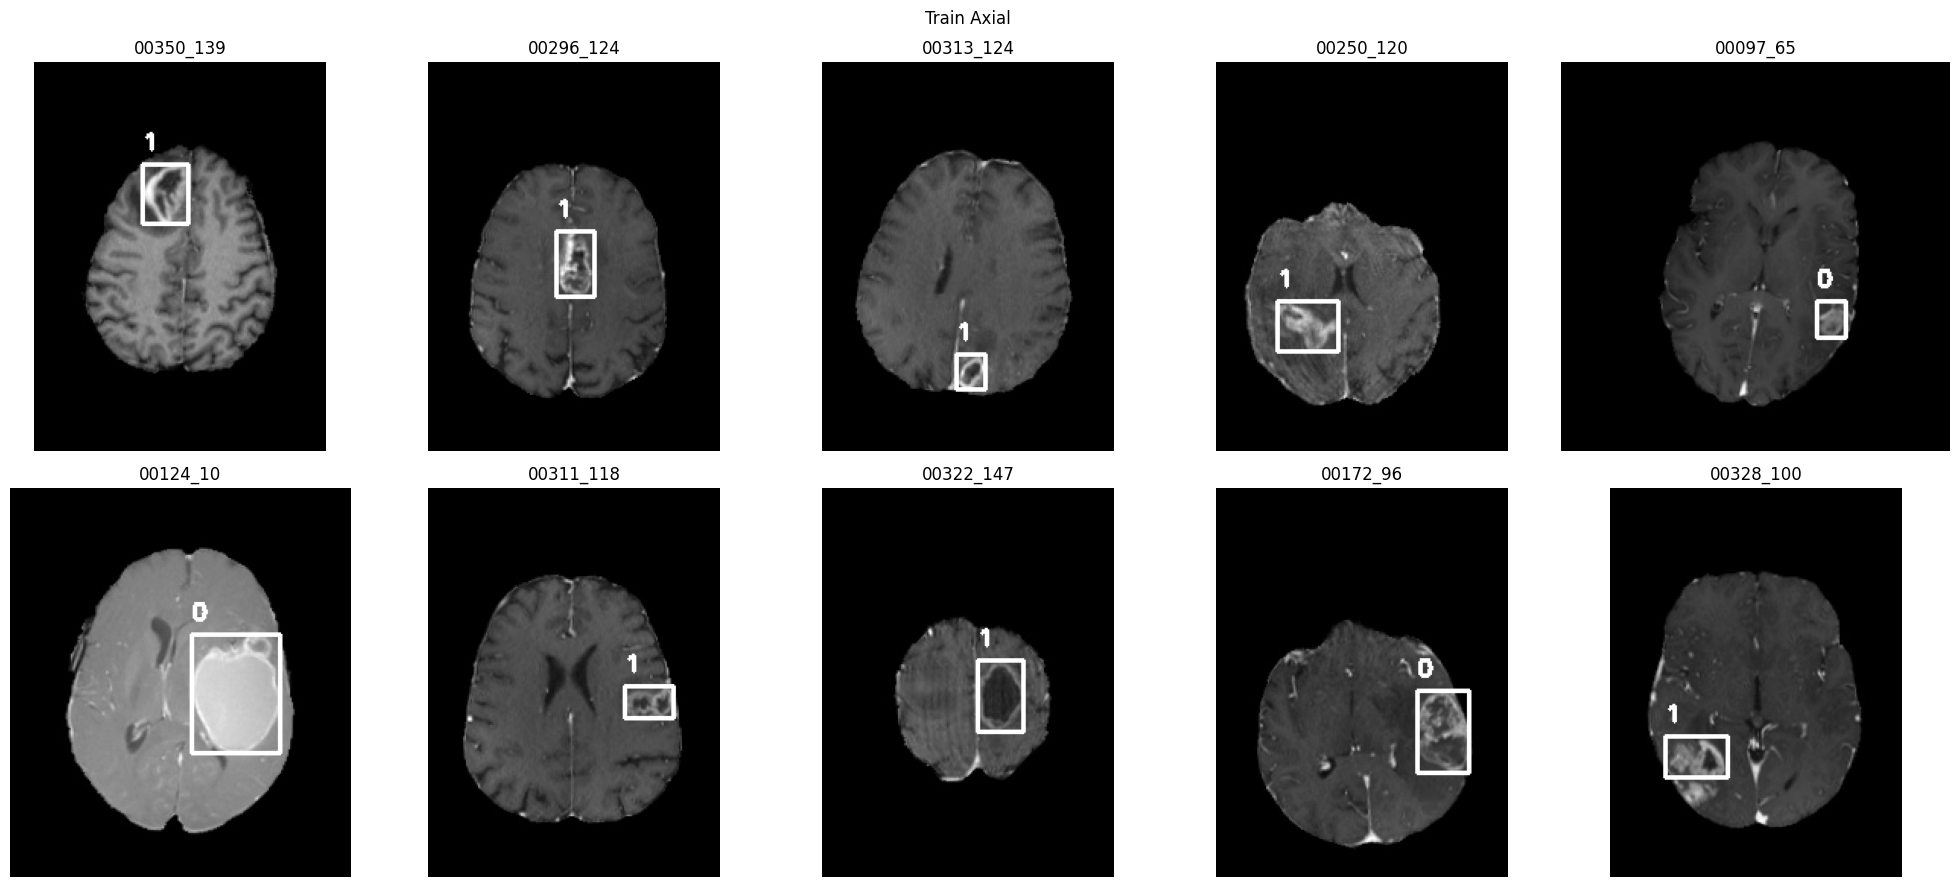

In [7]:
plot_images_with_bboxes(axial_image_train, axial_labels_train, axial_train_dataset + "labels", "Train Axial")

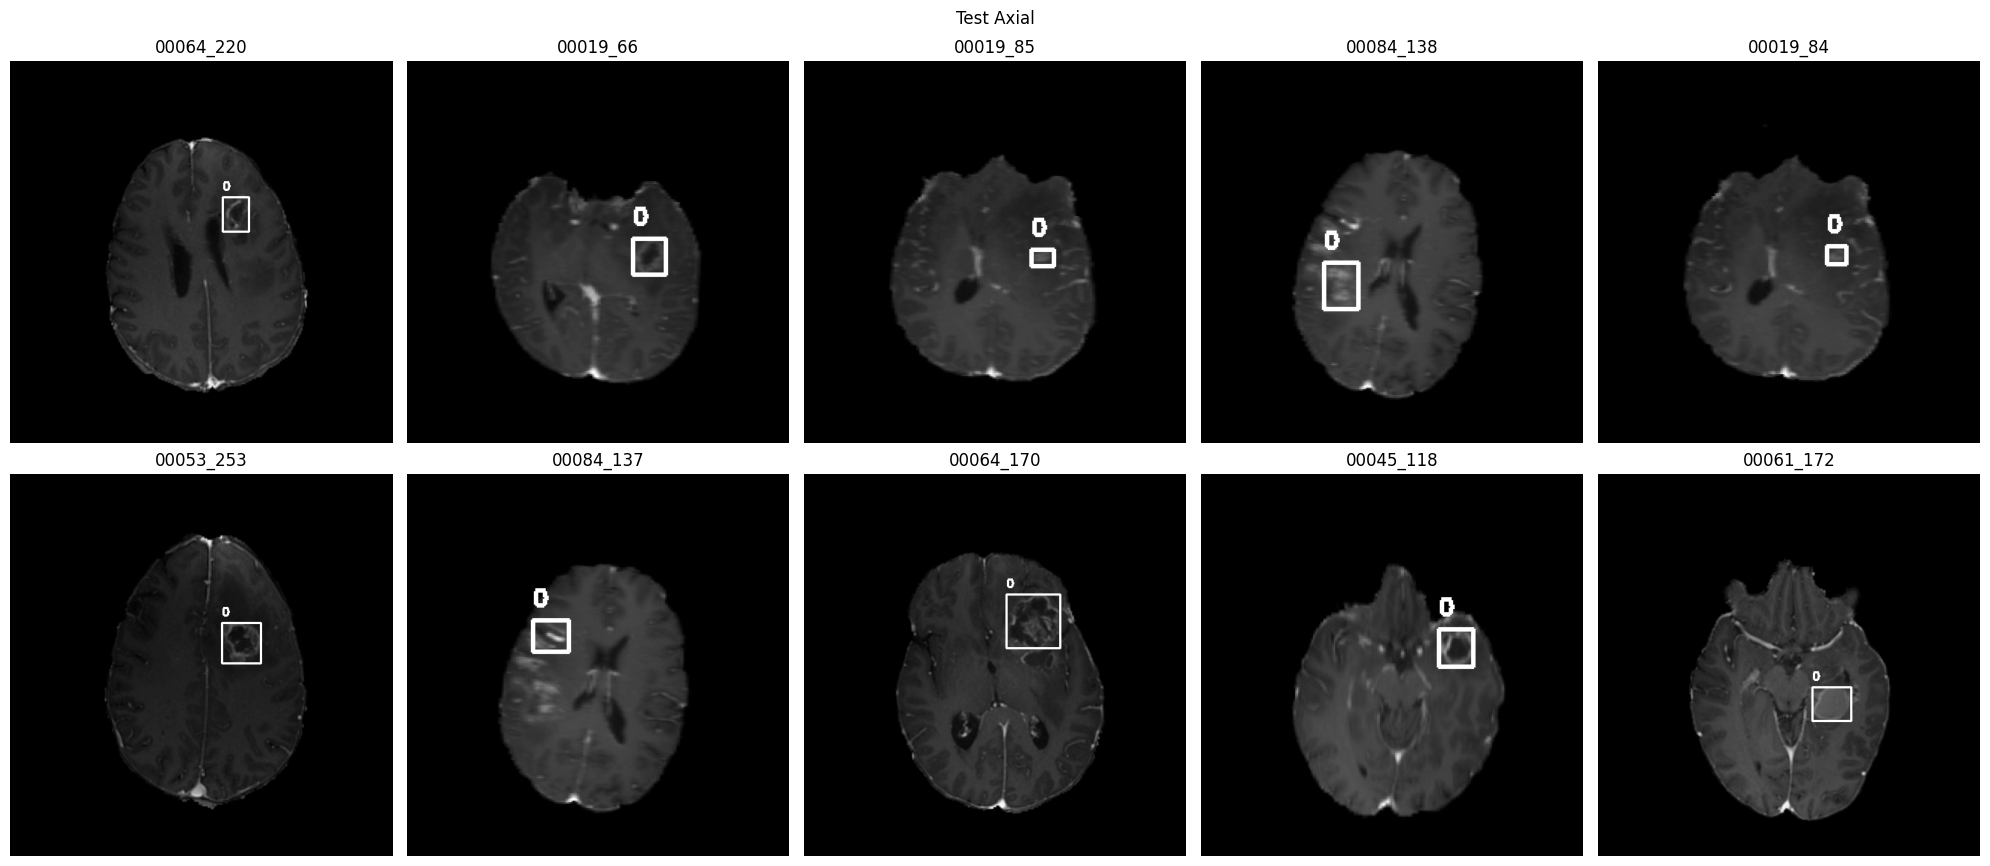

In [8]:
plot_images_with_bboxes(axial_image_test, axial_labels_test, axial_test_dataset + "labels", "Test Axial")